In [5]:
### DEV branch - to test adding E3SM

# dev 3 : use all arise members for efficiency bar plots, and add error bars

import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import json
from xmip.preprocessing import rename_cmip6
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 15})
import warnings
warnings.filterwarnings('ignore')

from HiLLA_utils import get_ds, spatial_mean, set_time_to_center_of_bounds, get_ssp245_ds, get_slice_annual_mean, yearly_timeseries

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, assessment_period, HiLLA_altitudes, path_archive, ens_mems_arise_UK, ens_mems_CE, CESM_ARISE_run_IDs, colours, model_colors, dark_model_colors, lat_band_dict

## read in the arise inj magnitudes, calculated from raw files in "x0_get_ARISE_injs.ipynb"
with open("../intermediate_outputs/arise_inj_mags.json", "r") as f:
    arise_injs = json.load(f)

In [6]:

# UKESM:
ds_HiLLA_13_UK = get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))
ds_HiLLA_15_UK = get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))

## repeat for CESM
ds_HiLLA_13_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))

## repeat for E3SM
ds_HiLLA_13_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))


## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK, '15km':ds_HiLLA_15_UK},
              'CESM':{'13km':ds_HiLLA_13_CE, '15km':ds_HiLLA_15_CE},
              'E3SM':{'13km':ds_HiLLA_13_E3, '15km':ds_HiLLA_15_E3}}



In [7]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_HiLLA_13_UK = weighted_annual_resample(get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_UK = weighted_annual_resample(get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069')), var='tas')

## repeat for CESM
ds_HiLLA_13_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## repeat for E3SM
ds_HiLLA_13_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK, '15km':ds_HiLLA_15_UK},
              'CESM':{'13km':ds_HiLLA_13_CE, '15km':ds_HiLLA_15_CE},
              'E3SM':{'13km':ds_HiLLA_13_E3, '15km':ds_HiLLA_15_E3}}


## reduce HiLLA data to annually resampled timeseries
timeseries_dicts_models = []
for model in models:
    timeseries_dicts = []
    for alt in HiLLA_altitudes:
        data = HiLLA_data[model][alt]
        timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))
    
    timeseries_dicts_models.append(dict(zip(HiLLA_altitudes, timeseries_dicts)))

HiLLA_timeseries_dict = dict(zip(models, timeseries_dicts_models))

In [8]:

HiLLA_13_ts_yearly_UK = yearly_timeseries(ds_HiLLA_13_UK, region='Global')
HiLLA_15_ts_yearly_UK = yearly_timeseries(ds_HiLLA_15_UK, region='Global')

HiLLA_13_ts_yearly_CE= yearly_timeseries(ds_HiLLA_13_CE, region='Global')
HiLLA_15_ts_yearly_CE = yearly_timeseries(ds_HiLLA_15_CE, region='Global')

HiLLA_13_ts_yearly_E3 = yearly_timeseries(ds_HiLLA_13_E3, region='Global')
HiLLA_15_ts_yearly_E3 = yearly_timeseries(ds_HiLLA_15_E3, region='Global')



HiLLA_13_ts_arctic_yearly_UK = yearly_timeseries(ds_HiLLA_13_UK, region='Arctic')
HiLLA_15_ts_arctic_yearly_UK = yearly_timeseries(ds_HiLLA_15_UK, region='Arctic')

HiLLA_13_ts_arctic_yearly_CE = yearly_timeseries(ds_HiLLA_13_CE, region='Arctic')
HiLLA_15_ts_arctic_yearly_CE = yearly_timeseries(ds_HiLLA_15_CE, region='Arctic')

HiLLA_13_ts_arctic_yearly_E3 = yearly_timeseries(ds_HiLLA_13_E3, region='Arctic')
HiLLA_15_ts_arctic_yearly_E3 = yearly_timeseries(ds_HiLLA_15_E3, region='Arctic')


HiLLA_13_ts_tropics_yearly_UK = yearly_timeseries(ds_HiLLA_13_UK, region='Tropics')
HiLLA_15_ts_tropics_yearly_UK = yearly_timeseries(ds_HiLLA_15_UK, region='Tropics')

HiLLA_13_ts_tropics_yearly_CE = yearly_timeseries(ds_HiLLA_13_CE, region='Tropics')
HiLLA_15_ts_tropics_yearly_CE = yearly_timeseries(ds_HiLLA_15_CE, region='Tropics')

HiLLA_13_ts_tropics_yearly_E3 = yearly_timeseries(ds_HiLLA_13_E3, region='Tropics')
HiLLA_15_ts_tropics_yearly_E3 = yearly_timeseries(ds_HiLLA_15_E3, region='Tropics')


In [9]:

###
HiLLA_13_abs_temp_UK = HiLLA_13_ts_yearly_UK.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()
HiLLA_15_abs_temp_UK = HiLLA_15_ts_yearly_UK.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()


HiLLA_13_abs_temp_CE = HiLLA_13_ts_yearly_CE.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()
HiLLA_15_abs_temp_CE = HiLLA_15_ts_yearly_CE.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()

HiLLA_13_abs_temp_E3 = HiLLA_13_ts_yearly_E3.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()
HiLLA_15_abs_temp_E3 = HiLLA_15_ts_yearly_E3.sel(year=slice('2050', '2069')).mean(['year']).tas.values.item()


In [10]:
DS_ssp245_tas_UK = get_slice_annual_mean(get_ssp245_ds(model='UKESM1-0-LL', centre='MOHC', variable='tas', 
                                 members=ens_mems_arise_UK, table='Amon', grid='gn'))

In [11]:
DS_ssp245_tas_CE = get_slice_annual_mean(get_ssp245_ds(model='CESM2-WACCM', centre='NCAR', variable='tas', 
                                 members=ens_mems_CE, table='Amon', grid='gn'))

In [12]:
ds_ssp245_tas_E3 =  xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'})
ds_ssp245_tas_E3 = get_slice_annual_mean(set_time_to_center_of_bounds(ds_ssp245_tas_E3, 'time_bnds'))

In [13]:
# SSP245 prep continued

def regional_means(ds, region):
    ds = ds.sel(y=slice(lat_band_dict[region][0], lat_band_dict[region][1]))
    weights = np.cos(np.deg2rad(ds['y']))
    ds_ts = ds.weighted(weights).mean(dim='y').mean('x')
    ens1_ssp245_tas_ts = ds_ts.isel(Ensemble_member=0).tas
    ensmean_ssp245_tas_ts = ds_ts.mean(dim='Ensemble_member').tas
    ensmax_ssp245_tas_ts = ds_ts.max(dim='Ensemble_member').tas
    ensmin_ssp245_tas_ts = ds_ts.min(dim='Ensemble_member').tas

    return {'ens1':ens1_ssp245_tas_ts, 'mean':ensmean_ssp245_tas_ts, 
            'max':ensmax_ssp245_tas_ts, 'min':ensmin_ssp245_tas_ts, 
            'all':ds_ts.tas}

In [14]:
# SSP245 prep continued


global_means_tas_UK = regional_means(DS_ssp245_tas_UK.rename({'latitude':'y', 'longitude':'x'}), region='Global')
global_means_tas_CE = regional_means(DS_ssp245_tas_CE.rename({'latitude':'y', 'longitude':'x'}), region='Global')

arctic_means_tas_UK = regional_means(DS_ssp245_tas_UK.rename({'latitude':'y', 'longitude':'x'}), region='Arctic')
arctic_means_tas_CE = regional_means(DS_ssp245_tas_CE.rename({'latitude':'y', 'longitude':'x'}), region='Arctic')

tropics_means_tas_UK = regional_means(DS_ssp245_tas_UK.rename({'latitude':'y', 'longitude':'x'}), region='Tropics')
tropics_means_tas_CE = regional_means(DS_ssp245_tas_CE.rename({'latitude':'y', 'longitude':'x'}), region='Tropics')

In [15]:
# E3 ssp245 prep
weights = np.cos(np.deg2rad(ds_ssp245_tas_E3['latitude']))
global_mean_tas_ssp245_E3 = ds_ssp245_tas_E3.mean('longitude').weighted(weights).mean(dim='latitude').tas

ds_ssp245_tas_arctic_E3 = ds_ssp245_tas_E3.sel(latitude=slice(lat_band_dict['Arctic'][0], lat_band_dict['Arctic'][1]))
weights = np.cos(np.deg2rad(ds_ssp245_tas_arctic_E3['latitude']))
arctic_mean_tas_ssp245_E3 = ds_ssp245_tas_arctic_E3.mean('longitude').weighted(weights).mean(dim='latitude').tas

ds_ssp245_tas_tropics_E3 = ds_ssp245_tas_E3.sel(latitude=slice(lat_band_dict['Tropics'][0], lat_band_dict['Tropics'][1]))
weights = np.cos(np.deg2rad(ds_ssp245_tas_tropics_E3['latitude']))
tropics_mean_tas_ssp245_E3 = ds_ssp245_tas_tropics_E3.mean('longitude').weighted(weights).mean(dim='latitude').tas


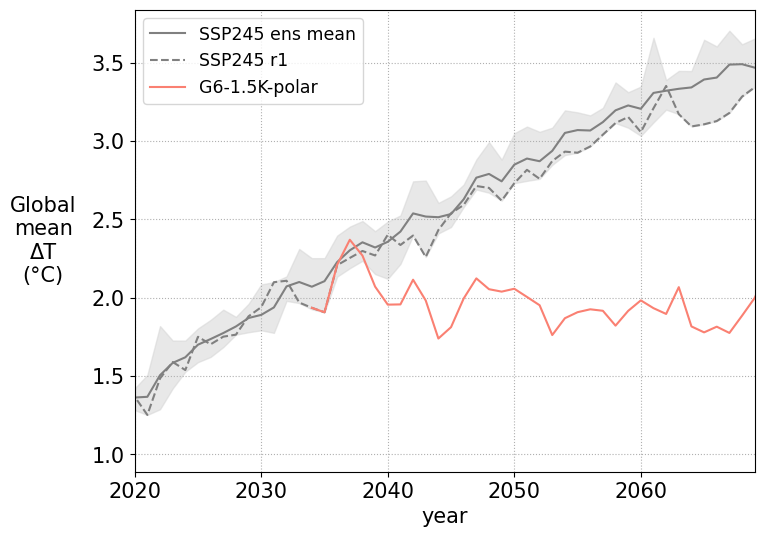

In [17]:
### STANDALONE: add a plot with G61.5Kpolar UKESM
MH_run_archive = '/gws/nopw/j04/moghli/MH_runs/'
def get_inj_mag_MH_ts(run):
    log = pd.read_csv(MH_run_archive + '{r}/FeedBack_stats_{rs}_2034.log'.format(r=run, rs=run.split('-')[1]))
    cols = ['30S(Tg)', '15S(Tg)', '15N(Tg)', '30N(Tg)']
    mean_inj = np.sum(log[col] for col in cols)
    if run in MH_EQ_runs:
        return mean_inj/2
    else:
        return mean_inj

def get_ds(run, var, table, zonal_mean=False):
    file = path_archive+'/{r}/{t}/{v}/{r}_{v}.nc'.format(r=run, t=table, v=var)
    ds = xr.open_dataset(file)
    if zonal_mean:
        ds = ds.mean(dim='longitude')
    return ds

tas_G6_13 = yearly_timeseries(get_ds(run = 'u-dj764', var='tas', table='Amon'), region='Global') # u-dm204dn587 is the 35 year run for 13km 60°

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
t_col = 'black'
model='UKESM'

tsdict = global_means_tas_UK
piCo_global = 286.48063434
#ax = axs[0]

(tsdict['mean'] - piCo_global).plot(ax=ax, c=colours['ssp245'], label='SSP245 ens mean')
ax.fill_between(tsdict['max'].year.values, 
                tsdict['min'].values - piCo_global, 
                tsdict['max'].values - piCo_global, 
                color=colours['ssp245_light'], alpha=0.5)
(tsdict['ens1'] - piCo_global).plot(ax=ax, c=colours['ssp245'], ls='--',
                                   label='SSP245 r1')
(tas_G6_13.tas - piCo_global).plot(ax=ax, c=model_colors[model], label='G6-1.5K-polar')
ax.grid(ls='dotted')
ax.legend(fontsize='small', ncols=1)
ax.set_xlim(2020, 2069)
ax.set_ylabel('Global\nmean\nΔT\n(°C)', 
              rotation=0, labelpad=35, va="center")
ax.set_title('')
plt.savefig('Figures/G6-1.5K-HiLLA_plot.jpg', dpi=300, bbox_inches='tight')

In [19]:
### also get ARISE temps

ds_list_tas = []
paths_tas = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/tas/gn/*/')

for path in paths_tas:
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc'))
    ds_list_tas.append(ds)

DS_ARISE_tas_UK = get_slice_annual_mean(xr.concat(ds_list_tas, dim='Ensemble_member'))
ARISE_global_means_tas_UK = regional_means(DS_ARISE_tas_UK, region='Global')
ARISE_arctic_means_tas_UK = regional_means(DS_ARISE_tas_UK, region='Arctic')
ARISE_tropics_means_tas_UK = regional_means(DS_ARISE_tas_UK, region='Tropics')


## repeat for CESM
ds_list_tas = []
path = '/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/arise/TREFHT/'
files = os.listdir(path)
files = [x for x in files if ".nc" in x]

# we keep only first 5 members to align with the ssp245 runs available
# this also means there are 5 members for both models, making figures easier to interpret
files = [x for x in files if int(x.split('.')[5]) < 6] 


for file in files:
    ds = rename_cmip6(xr.open_mfdataset(path+file))
    ds['Ensemble_member'] = file.split('.')[5]
    ds_list_tas.append(ds)
DS_ARISE_tas_CE = get_slice_annual_mean(xr.concat(ds_list_tas, dim='Ensemble_member'))['TREFHT'].to_dataset(name='tas')
ARISE_global_means_tas_CE = regional_means(DS_ARISE_tas_CE, region='Global')
ARISE_arctic_means_tas_CE = regional_means(DS_ARISE_tas_CE, region='Arctic')
ARISE_tropics_means_tas_CE = regional_means(DS_ARISE_tas_CE, region='Tropics')

### also get the SSP245 ARISE runs for CESM
ds_list_tas = []
path = '/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/ssp245/TREFHT/'
files = os.listdir(path)
files = [x for x in files if ".nc" in x]
# we keep only first 5 members to align with the ssp245 runs available
# this also means there are 5 members for both models, making figures easier to interpret
for member in CESM_ARISE_run_IDs:
    member_files = [x for x in files if x.split('.')[6] == member] 
    paths = [path+file for file in member_files]
    ds = rename_cmip6(xr.open_mfdataset(paths))
    ds['Ensemble_member'] = member
    ds_list_tas.append(ds)
DS_SSP245_ARISE_tas_CE = get_slice_annual_mean(xr.concat(ds_list_tas, dim='Ensemble_member'))['TREFHT'].to_dataset(name='tas')
SSP245_ARISE_global_means_tas_CE = regional_means(DS_SSP245_ARISE_tas_CE, 'Global')
SSP245_ARISE_arctic_means_tas_CE = regional_means(DS_SSP245_ARISE_tas_CE, 'Arctic')
SSP245_ARISE_tropics_means_tas_CE = regional_means(DS_SSP245_ARISE_tas_CE, 'Tropics')



ARISE_abs_temp_UK = ARISE_global_means_tas_UK['mean'].sel(year=slice('2050', '2069')).mean(['year']).item()
ARISE_abs_temp_CE = ARISE_global_means_tas_CE['mean'].sel(year=slice('2050', '2069')).mean(['year']).values.item()

In [ ]:
def get_period_matching_T(ts, T, length=20):
    diffs = []
    for start_year in ts.year.values:
        test = ts.sel(year=slice(start_year, start_year+length-1))
        #print(test)
        mean = test.mean('year').values.item()
        #print(mean - 286.48063434)
        diff = mean - T
        diffs.append(diff)
    #print(diffs)
    pos = np.argmin(np.abs(diffs))
    #print(pos)
    crit_year = ts.year.values[pos]
    #print(crit_year)
    out = ts.sel(year=slice(crit_year, crit_year+length-1))
    #print(out.mean('year').item() - T)
    return crit_year

HiLLA_13_crit_year_UK = get_period_matching_T(global_means_tas_UK['mean'],HiLLA_13_abs_temp_UK)
HiLLA_15_crit_year_UK = get_period_matching_T(global_means_tas_UK['mean'],HiLLA_15_abs_temp_UK)
ARISE_crit_year_UK = get_period_matching_T(global_means_tas_UK['mean'], ARISE_abs_temp_UK, length=18)

HiLLA_13_crit_year_CE = get_period_matching_T(global_means_tas_CE['mean'],HiLLA_13_abs_temp_CE)
HiLLA_15_crit_year_CE = get_period_matching_T(global_means_tas_CE['mean'],HiLLA_15_abs_temp_CE)
ARISE_crit_year_CE = get_period_matching_T(global_means_tas_CE['mean'], ARISE_abs_temp_CE)


### ERROR - the below doesn't work because my E3SM background ssp245 run starts in 2035, but i need earlier to match the temp. 
HiLLA_13_crit_year_E3 = get_period_matching_T(global_mean_tas_ssp245_E3, HiLLA_13_abs_temp_E3)
HiLLA_15_crit_year_E3 = get_period_matching_T(global_mean_tas_ssp245_E3, HiLLA_15_abs_temp_E3)

In [ ]:
y1, y2 = assessment_period[0], assessment_period[1]

ds_ssp245_UK_ms = DS_ssp245_tas_UK.sel(year=slice(y1, y2)).mean(['year'])#.rename({'x':'longitude', 'y':'latitude'})
HiLLA_13_cooling_UK = get_slice_annual_mean(ds_HiLLA_13_UK).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_UK_ms.isel(Ensemble_member=0)
HiLLA_15_cooling_UK = get_slice_annual_mean(ds_HiLLA_15_UK).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_UK_ms.isel(Ensemble_member=0)
ARISE_cooling_UK = DS_ARISE_tas_UK.sel(year=slice(y1, y2)).mean(['year', 'Ensemble_member']).rename({'x':'longitude', 'y':'latitude'}) - ds_ssp245_UK_ms.mean('Ensemble_member')


ds_ssp245_CE_ms = DS_ssp245_tas_CE.sel(year=slice(y1, y2)).mean(['year'])#.rename({'x':'longitude', 'y':'latitude'})
HiLLA_13_cooling_CE = get_slice_annual_mean(ds_HiLLA_13_CE).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_CE_ms.isel(Ensemble_member=0)
HiLLA_15_cooling_CE = get_slice_annual_mean(ds_HiLLA_15_CE).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_CE_ms.isel(Ensemble_member=0)
ARISE_cooling_CE = DS_ARISE_tas_CE.sel(year=slice(y1, y2)).mean(['year', 'Ensemble_member']).rename({'x':'longitude', 'y':'latitude'}) - ds_ssp245_CE_ms.mean('Ensemble_member')

ds_ssp245_E3_ms = ds_ssp245_tas_E3.sel(year=slice(y1, y2)).mean(['year'])
HiLLA_13_cooling_E3 = get_slice_annual_mean(ds_HiLLA_13_E3).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_E3_ms
HiLLA_15_cooling_E3 = get_slice_annual_mean(ds_HiLLA_15_E3).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_E3_ms

## def a normalised 'overcooling' metric as 
## Delta T from 'target' per degree global mean cooling

# UKESM
ds_ssp245_UK_ms_HiLLA_13_temp = DS_ssp245_tas_UK.sel(year=slice(HiLLA_13_crit_year_UK, HiLLA_13_crit_year_UK+19)).mean(['year'])
HiLLA_13_delta_targ_UK = get_slice_annual_mean(ds_HiLLA_13_UK).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_UK_ms_HiLLA_13_temp.isel(Ensemble_member=0)
ds_ssp245_UK_ms_HiLLA_15_temp = DS_ssp245_tas_UK.sel(year=slice(HiLLA_15_crit_year_UK, HiLLA_15_crit_year_UK+19)).mean(['year'])
HiLLA_15_delta_targ_UK = get_slice_annual_mean(ds_HiLLA_15_UK).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_UK_ms_HiLLA_15_temp.isel(Ensemble_member=0)
ds_ssp245_UK_ms_ARISE_temp = DS_ssp245_tas_UK.sel(year=slice(ARISE_crit_year_UK, ARISE_crit_year_UK+19)).mean(['year'])
ARISE_delta_targ_UK = DS_ARISE_tas_UK.sel(year=slice(y1, y2)).mean(['year', 'Ensemble_member']) - ds_ssp245_UK_ms_ARISE_temp.mean('Ensemble_member')

# CESM
ds_ssp245_CE_ms_HiLLA_13_temp = DS_ssp245_tas_CE.sel(year=slice(HiLLA_13_crit_year_CE, HiLLA_13_crit_year_CE+19)).mean(['year'])
HiLLA_13_delta_targ_CE = get_slice_annual_mean(ds_HiLLA_13_CE).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_CE_ms_HiLLA_13_temp.isel(Ensemble_member=0)
ds_ssp245_CE_ms_HiLLA_15_temp = DS_ssp245_tas_CE.sel(year=slice(HiLLA_15_crit_year_CE, HiLLA_15_crit_year_CE+19)).mean(['year'])
HiLLA_15_delta_targ_CE = get_slice_annual_mean(ds_HiLLA_15_CE).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_CE_ms_HiLLA_15_temp.isel(Ensemble_member=0)
ds_ssp245_CE_ms_ARISE_temp = DS_ssp245_tas_CE.sel(year=slice(ARISE_crit_year_CE, ARISE_crit_year_CE+19)).mean(['year'])
ARISE_delta_targ_CE = DS_ARISE_tas_CE.sel(year=slice(y1, y2)).mean(['year', 'Ensemble_member']) - ds_ssp245_CE_ms_ARISE_temp.mean('Ensemble_member')

# E3SM
ds_ssp245_E3_ms_HiLLA_13_temp = ds_ssp245_tas_E3.sel(year=slice(HiLLA_13_crit_year_E3, HiLLA_13_crit_year_E3+19)).mean(['year'])
HiLLA_13_delta_targ_E3 = get_slice_annual_mean(ds_HiLLA_13_E3).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_E3_ms_HiLLA_13_temp
ds_ssp245_E3_ms_HiLLA_15_temp = ds_ssp245_tas_E3.sel(year=slice(HiLLA_15_crit_year_E3, HiLLA_15_crit_year_E3+19)).mean(['year'])
HiLLA_15_delta_targ_E3 = get_slice_annual_mean(ds_HiLLA_15_E3).sel(year=slice(y1, y2)).mean('year') - ds_ssp245_E3_ms_HiLLA_15_temp


In [ ]:
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [ ]:

cols = 'YlGnBu_r'
clevs=np.arange(-2.25,0.2,0.25) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(12,6))

ax = axs.flatten()[0]
ax.set_title('(a) \u0394T; ARISE; UKESM1')
d = ARISE_cooling_UK.tas/(np.mean([x for x in arise_injs['UKESM'].values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[1]
ax.set_title('(b) \u0394T; HiLLA-15; UKESM1')
d = HiLLA_15_cooling_UK.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[2]
ax.set_title('(c) \u0394T; ARISE; CESM2-WACCM')
d = ARISE_cooling_CE.tas/(np.mean([x for x in arise_injs['CESM'].values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[3]
ax.set_title('(d) \u0394T; HiLLA-15; CESM2-WACCM')
d = HiLLA_15_cooling_CE.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()
#sig_mask,lons=add_cyclic_point(models_agree, coord=models_agree['x'])
#cs_hatch = ax.contourf(lons,models_agree['y'],sig_mask,
#                       transform = ccrs.PlateCarree(),
#                       levels=[0, 0.2, 1.2], colors='none',
 #                      hatches=[None,'..', '..'],
#                       extend='neither', zorder=1000)


plt.tight_layout()
# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.87, 0.2, 0.05, 0.6])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('\u0394T\nper 10Tg\ninjection\n(°C)', rotation=0, labelpad=40)
cbar.ax.yaxis.label.set_va('center')
#
plt.savefig('Figures/spatial_tas_response_abs.jpg', dpi=300)

In [ ]:


cols = 'YlGnBu_r'
clevs=np.arange(-2.25,0.2,0.25) 

fig, axs = plt.subplots(nrows=2,ncols=3,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(16,6))

ax = axs.flatten()[0]
ax.set_title('(a) \u0394T; ARISE; UKESM1')
d = ARISE_cooling_UK.tas/(np.mean([x for x in arise_injs_UK.values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[1]
ax.set_title('(b) \u0394T; HILLA-13; UKESM1')
d = HiLLA_13_cooling_UK.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[2]
ax.set_title('(c) \u0394T; HILLA-15; UKESM1')
d = HiLLA_15_cooling_UK.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[3]
ax.set_title('(d) \u0394T; ARISE; CESM2-WACCM')
d = ARISE_cooling_CE.tas/(np.mean([x for x in arise_injs_CE.values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[4]
ax.set_title('(e) \u0394T; HILLA-13; CESM2-WACCM')
d = HiLLA_13_cooling_CE.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[5]
ax.set_title('(f) \u0394T; HILLA-15; CESM2-WACCM')
d = HiLLA_15_cooling_CE.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()
#sig_mask,lons=add_cyclic_point(models_agree, coord=models_agree['x'])
#cs_hatch = ax.contourf(lons,models_agree['y'],sig_mask,
#                       transform = ccrs.PlateCarree(),
#                       levels=[0, 0.2, 1.2], colors='none',
 #                      hatches=[None,'..', '..'],
#                       extend='neither', zorder=1000)


plt.tight_layout()
# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.87, 0.2, 0.025, 0.6])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('\u0394T\nper 10Tg\ninjection\n(°C)', rotation=0, labelpad=40)
cbar.ax.yaxis.label.set_va('center')
#
plt.savefig('Figures/spatial_tas_response_absv2.jpg', dpi=300, bbox_inches='tight')

In [ ]:
arise_cooling_UK_scalar

In [ ]:
### plot under/overcooling:

cols = 'bwr'
clevs=np.arange(-1,1.1,0.25) 

fig, axs = plt.subplots(nrows=2,ncols=3,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(16,6))

ax = axs.flatten()[0]
ax.set_title('(a) \u0394T; ARISE; UKESM1')
d = -ARISE_delta_targ_UK.tas/arise_cooling_UK_scalar.mean('Ensemble_member')
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[1]
ax.set_title('(b) \u0394T; HiLLA-13; UKESM1')
d = -HiLLA_13_delta_targ_UK.tas/HiLLA_13_cooling_UK_scalar
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[2]
ax.set_title('(c) \u0394T; HiLLA-15; UKESM1')
d = -HiLLA_15_delta_targ_UK.tas/HiLLA_15_cooling_UK_scalar
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()


ax = axs.flatten()[3]
ax.set_title('(d) \u0394T; ARISE; CESM2-WACCM')
d = -ARISE_delta_targ_CE.tas/arise_cooling_CE_scalar.mean('Ensemble_member')
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[4]
ax.set_title('(e) \u0394T; HiLLA-13; CESM2-WACCM')
d = -HiLLA_13_delta_targ_CE.tas/HiLLA_13_cooling_CE_scalar
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[5]
ax.set_title('(f) \u0394T; HiLLA-15; CESM2-WACCM')
d = -HiLLA_15_delta_targ_CE.tas/HiLLA_15_cooling_CE_scalar
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

#sig_mask,lons=add_cyclic_point(models_agree, coord=models_agree['x'])
#cs_hatch = ax.contourf(lons,models_agree['y'],sig_mask,
#                       transform = ccrs.PlateCarree(),
#                       levels=[0, 0.2, 1.2], colors='none',
 #                      hatches=[None,'..', '..'],
#                       extend='neither', zorder=1000)


plt.tight_layout()
# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.87, 0.2, 0.025, 0.6])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('\u0394T\nvs target\n(°C/°C)', rotation=0, labelpad=40)
cbar.ax.yaxis.label.set_va('center')
#
plt.savefig('Figures/spatial_tas_response_under_overcooling.jpg', dpi=300, bbox_inches='tight')

In [ ]:
### plus zonal mean version:

linestyle_dict = {'ARISE':'solid', 'HiLLA-13':'dashed', 'HiLLA-15':'dotted'}
scens =['ARISE', 'HiLLA-13', 'HiLLA-15']
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True, sharey=True)

i=0
for d in [-ARISE_delta_targ_UK.tas/arise_cooling_UK_scalar.mean('Ensemble_member'),
          -HiLLA_13_delta_targ_UK.tas/HiLLA_13_cooling_UK_scalar,
          -HiLLA_15_delta_targ_UK.tas/HiLLA_15_cooling_UK_scalar]:
    dm = d.mean('longitude')
    axs[0].plot(dm.latitude, dm.values, ls=linestyle_dict[scens[i]], color=model_colors['UKESM'])
    axs[0].set_title('(a) UKESM1', fontsize='medium')
    i=i+1

i=0
for d in [-ARISE_delta_targ_CE.tas/arise_cooling_CE_scalar.mean('Ensemble_member'),
          -HiLLA_13_delta_targ_CE.tas/HiLLA_13_cooling_CE_scalar,
          -HiLLA_15_delta_targ_CE.tas/HiLLA_15_cooling_CE_scalar]:
    dm = d.mean('longitude')
    axs[1].plot(dm.latitude, dm.values, ls=linestyle_dict[scens[i]], color=model_colors['CESM'], label=scens[i])
    axs[1].legend(fontsize='small', loc='upper right')
    axs[1].set_title('(b) CESM2-WACCM', fontsize='medium')
    i=i+1
    
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
fig.supxlabel('Latitude (°)',  fontsize='medium')
fig.supylabel('\u0394T\n(°C/°C)', rotation=0, ha='center', fontsize='medium')
#plt.tight_layout()
plt.savefig('Figures/under_over_cooling_zonal.jpg', dpi=300, bbox_inches='tight')

In [ ]:
import matplotlib.lines as mlines

linestyle_dict = {'ARISE':'solid', 'HiLLA-13':'dashed', 'HiLLA-15':'dotted'}
scens = ['ARISE', 'HiLLA-13', 'HiLLA-15']

fig, ax = plt.subplots(figsize=(5, 6))

# Plot UKESM1
for i, d in enumerate([
    -ARISE_delta_targ_UK.tas / arise_cooling_UK_scalar.mean('Ensemble_member'),
    -HiLLA_13_delta_targ_UK.tas / HiLLA_13_cooling_UK_scalar,
    -HiLLA_15_delta_targ_UK.tas / HiLLA_15_cooling_UK_scalar
]):
    dm = d.mean('longitude')
    ax.plot(dm.values, dm.latitude, ls=linestyle_dict[scens[i]], color=model_colors['UKESM'])

# Plot CESM2-WACCM
for i, d in enumerate([
    -ARISE_delta_targ_CE.tas / arise_cooling_CE_scalar.mean('Ensemble_member'),
    -HiLLA_13_delta_targ_CE.tas / HiLLA_13_cooling_CE_scalar,
    -HiLLA_15_delta_targ_CE.tas / HiLLA_15_cooling_CE_scalar
]):
    dm = d.mean('longitude')
    ax.plot(dm.values, dm.latitude, ls=linestyle_dict[scens[i]], color=model_colors['CESM'])

# Model legend handles (color-coded solid lines)
model_handles = [
    mlines.Line2D([], [], color=model_colors['UKESM'], linestyle='solid', label='UKESM1'),
    mlines.Line2D([], [], color=model_colors['CESM'], linestyle='solid', label='CESM2-\nWACCM')
]

# Scenario legend handles (gray linestyles)
scenario_handles = [
    mlines.Line2D([], [], color='gray', linestyle=linestyle_dict[scen], label=scen)
    for scen in scens
]

# Add first legend (model colors)
#legend1 = ax.legend(handles=model_handles, fontsize='small', loc='center right')

# Add second legend (linestyles), below or beside first legend
legend2 = ax.legend(handles=scenario_handles+model_handles, fontsize='small', loc='center left')

# Add back first legend manually (so it doesn't get overwritten)
#ax.add_artist(legend1)

# Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(ls='dotted')

ax.set_xlabel('\u0394T (°C/°C)', fontsize='medium')
ax.set_ylabel('Latitude (°)', fontsize='medium')
plt.tight_layout()
plt.savefig('Figures/under_over_cooling_zonal_vertical_combined.jpg', dpi=300, bbox_inches='tight')


In [ ]:
### also do a % of cooling plot: 

HiLLA_13_frac_UK = (HiLLA_13_cooling_UK.tas/12)/(ARISE_cooling_UK.tas/np.mean([x for x in arise_injs_UK.values()]))
HiLLA_15_frac_UK = (HiLLA_15_cooling_UK.tas/12)/(ARISE_cooling_UK.tas/np.mean([x for x in arise_injs_UK.values()]))

HiLLA_13_frac_CE = (HiLLA_13_cooling_CE.tas/12)/(ARISE_cooling_CE.tas/np.mean([x for x in arise_injs_CE.values()]))
HiLLA_15_frac_CE = (HiLLA_15_cooling_CE.tas/12)/(ARISE_cooling_CE.tas/np.mean([x for x in arise_injs_CE.values()]))

## repeat the two plots above, now with hadgem for baseline adjustment

### use mm-mean to generate baseline adjustment

cols = 'Spectral'
clevs=np.arange(0,121,20) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(12,6))

ax = axs.flatten()[0]
ax.set_title('(a) UKESM1; HiLLA-13')
d = 100*HiLLA_13_frac_UK
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[1]
ax.set_title('(b) UKESM1; HiLLA-15')
d = 100*HiLLA_15_frac_UK
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()


ax = axs.flatten()[2]
ax.set_title('(c) CESM2-WACCM; HiLLA-13')
d = 100*HiLLA_13_frac_CE
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[3]
ax.set_title('(d) CESM2-WACCM; HiLLA-15')
d = 100*HiLLA_15_frac_CE
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()


plt.tight_layout()
# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.87, 0.3, 0.05, 0.4])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('% of ARISE\ncooling\n(per unit inj.)', rotation=0, labelpad=45)
cbar.ax.yaxis.label.set_va('center')
#
plt.savefig('Figures/spatial_tas_frac_arise.jpg', dpi=300, bbox_inches='tight')

# Now repeat the map plots, this time including E3SM:



In [ ]:
cols = 'YlGnBu_r'
clevs=np.arange(-2.25,0.2,0.25) 
titles = ['(a) HiLLA-13; UKESM1', 
          '(b) HiLLA-13; CESM2-WACCM', 
          '(c) HiLLA-13; E3SM',
          '(d) HiLLA-15; UKESM1', 
          '(e) HiLLA-15; CESM2-WACCM', 
          '(f) HiLLA-15; E3SM']

fig, axs = plt.subplots(nrows=2,ncols=3,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(16,6))
i=0
for d in [HiLLA_13_cooling_UK.tas, HiLLA_13_cooling_CE.tas, HiLLA_13_cooling_E3.tas,
          HiLLA_15_cooling_UK.tas, HiLLA_15_cooling_CE.tas, HiLLA_15_cooling_E3.tas]:
    
    if i in [2, 5]: # E3SM regridding didn't extrapolate outside the convex hull, so need to do this now for pretty plots
        d = d.interpolate_na(dim="longitude", method="linear", fill_value="extrapolate").interpolate_na(dim="latitude", method="linear", fill_value="extrapolate")
    
    ax = axs.flatten()[i]
    data,lons=add_cyclic_point(d,coord=d['longitude'])
    cs=ax.contourf(lons,d['latitude'],data,clevs,
                   transform = ccrs.PlateCarree(),
                   cmap=cols,
                   extend='both')
    ax.coastlines()
    ax.set_title(titles[i])
    
    i=i+1

plt.tight_layout()
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)
cbar_ax = fig.add_axes([0.87, 0.2, 0.025, 0.6])
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('\u0394T\n(°C)', rotation=0, labelpad=40)
cbar.ax.yaxis.label.set_va('center')
#
plt.savefig('Figures/spatial_tas_response_allmods.jpg', dpi=300, bbox_inches='tight')

In [ ]:
### also plot the under/over-cooling

cols = 'bwr'
clevs=np.arange(-1,1.1,0.25) 

fig, axs = plt.subplots(nrows=2,ncols=3,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(16,6))

i=0
for d in [-HiLLA_13_delta_targ_UK.tas/HiLLA_13_cooling_UK_scalar, 
          -HiLLA_13_delta_targ_CE.tas/HiLLA_13_cooling_CE_scalar,
          -HiLLA_13_delta_targ_E3.tas/HiLLA_13_cooling_E3_scalar,
          -HiLLA_15_delta_targ_UK.tas/HiLLA_15_cooling_UK_scalar, 
          -HiLLA_15_delta_targ_CE.tas/HiLLA_15_cooling_CE_scalar,
          -HiLLA_15_delta_targ_E3.tas/HiLLA_15_cooling_E3_scalar]:
          
    ax = axs.flatten()[i]
    ax.set_title(titles[i])
    if i in [2, 5]: # E3SM regridding didn't extrapolate outside the convex hull, so need to do this now for pretty plots
        d = d.interpolate_na(dim="longitude", method="linear", fill_value="extrapolate").interpolate_na(dim="latitude", method="linear", fill_value="extrapolate")
    
    data,lons=add_cyclic_point(d,coord=d['longitude'])
    cs=ax.contourf(lons,d['latitude'],data,clevs,
                   transform = ccrs.PlateCarree(),
                   cmap=cols,
                   extend='both')
    ax.coastlines()
    i=i+1

plt.tight_layout()
# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.87, 0.2, 0.025, 0.6])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('\u0394T\nvs target\n(°C/°C)', rotation=0, labelpad=40)
cbar.ax.yaxis.label.set_va('center')
#
""" DOESNT WORK """
#plt.savefig('Figures/spatial_tas_response_under_overcooling_all3mods.jpg', dpi=300, bbox_inches='tight')

We don’t have the background data for E3SM to make the above plot. But we could make a similar version, as °C/°C cooling - °C/°C warming (ssp245). This should look pretty similar, but the target is a shape of ratios, derived from the linregress under SSP245. 
